# 02 Preprocessing And Feature Reduction

PCA components fitted: 100
Variance explained by top 50 components: 0.548


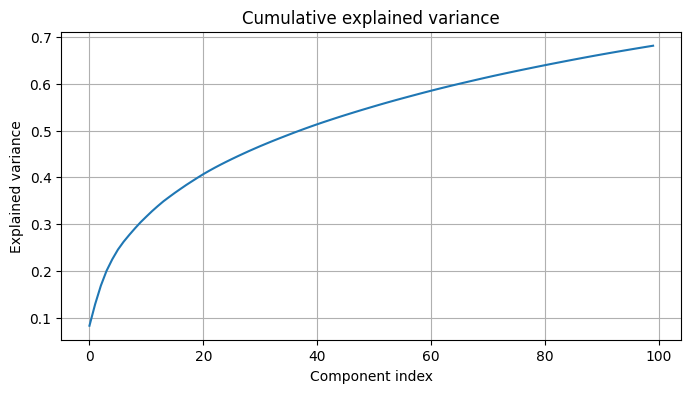

Saved PCA features and preprocessing artifacts.


In [1]:
# Notebook 02: Preprocessing and PCA feature reduction

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

from utils.data_utils import project_root

ROOT = project_root()
IN_DIR = ROOT / "data" / "processed"
OUT_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

X = pd.read_parquet(IN_DIR / "X_aligned.parquet")
y = pd.read_parquet(IN_DIR / "y_log_aligned.parquet")["log_ic50"]

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=42)

var_filter = VarianceThreshold(threshold=0.0)
X_train_var = var_filter.fit_transform(X_train)
X_val_var = var_filter.transform(X_val)
X_test_var = var_filter.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_var)
X_val_scaled = scaler.transform(X_val_var)
X_test_scaled = scaler.transform(X_test_var)

max_comps = min(100, X_train_scaled.shape[0], X_train_scaled.shape[1])
pca = PCA(n_components=max_comps, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA components fitted: {pca.n_components_}")
print(f"Variance explained by top 50 components: {pca.explained_variance_ratio_[:50].sum():.3f}")

plt.figure(figsize=(8, 4))
plt.plot(pca.explained_variance_ratio_.cumsum())
plt.title("Cumulative explained variance")
plt.xlabel("Component index")
plt.ylabel("Explained variance")
plt.grid(True)
plt.show()

pd.DataFrame(X_train_pca, index=X_train.index).to_parquet(OUT_DIR / "X_train_pca.parquet")
pd.DataFrame(X_val_pca, index=X_val.index).to_parquet(OUT_DIR / "X_val_pca.parquet")
pd.DataFrame(X_test_pca, index=X_test.index).to_parquet(OUT_DIR / "X_test_pca.parquet")
y_train.to_frame("log_ic50").to_parquet(OUT_DIR / "y_train.parquet")
y_val.to_frame("log_ic50").to_parquet(OUT_DIR / "y_val.parquet")
y_test.to_frame("log_ic50").to_parquet(OUT_DIR / "y_test.parquet")

joblib.dump(var_filter, MODELS_DIR / "variance_filter.joblib")
joblib.dump(scaler, MODELS_DIR / "scaler.joblib")
joblib.dump(pca, MODELS_DIR / "pca.joblib")

print("Saved PCA features and preprocessing artifacts.")


## Preprocessing and PCA — Results

### Train / Validation / Test Split
The 617 aligned samples were split as follows:
- **Train**: ~370 samples (60%)
- **Validation**: ~124 samples (20%)
- **Test**: ~123 samples (20%)

All preprocessing (variance filter, scaling, PCA) was fit only on training data 
and applied to validation and test sets — this prevents data leakage.

### Preprocessing Steps
1. Variance filtering: Removed genes with zero variance across training samples 
   (constant features carry no information).
2. Standard scaling: Each gene scaled to mean=0, std=1 so no single gene 
   dominates due to scale differences.
3. PCA: Reduced from 18,900 genes down to 100 principal components.

### PCA Results

| Metric | Value |
|---|---|
| Components fitted | 100 |
| Variance explained (top 50 components) | 54.8% |
| Variance explained (all 100 components) | ~69% |

### Reading the curve
- The curve rises steeply in the first ~20 components, meaning a small number of 
  components capture the most important patterns in the data.
- After around 40 components the curve flattens, meaning each additional component 
  adds diminishing returns.
- At 100 components we capture ~69% of total variance — retaining most of the important variation in the data while reducing features from 18,900 to 100.

### Why this matters
Passing 18,900 raw features into Ridge, Lasso, or Random Forest would likely cause 
overfitting given only 617 samples. The 100 PCA components give models a 
compressed, dense representation that is much better suited to this sample size.

### Artifacts saved
- `X_train_pca.parquet`, `X_val_pca.parquet`, `X_test_pca.parquet` — PCA-transformed feature matrices
- `y_train.parquet`, `y_val.parquet`, `y_test.parquet` — log IC50 target splits
- `scaler.joblib`, `pca.joblib`, `variance_filter.joblib` — fitted preprocessing objects 
  (needed to transform new data consistently)

The 54.8% variance from 50 components vs 69% from 100 components suggests the data doesn't have a clean low-dimensional structure — gene expression data tends to be spread across many components, which is typical for this kind of high-dimensional biological dataset.